# Data Understanding and Preparation
Covers **Stage 1 + 2.1.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports.
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** —
- *Provided (no change):* `config.py`.
- *Provided to extend:* `src/data_prep.py` (function stubs).
- *You build:* this notebook + the report.

Prereqs: `pip install -r requirements.txt`; extract the Kaggle casting dataset under `data/` (train/test → ok_front/def_front).

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import sys

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Casting_Defect_MLOps_Capstone"
)

DATASET_DIR = PROJECT_DIR / "data"

if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_DIR}")

if not DATASET_DIR.is_dir():
    raise FileNotFoundError(f"Dataset folder not found: {DATASET_DIR}")

os.chdir(PROJECT_DIR)

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

# Create output folders if needed.
for folder in ["artifacts", "artifacts/splits", "mlruns"]:
    (PROJECT_DIR / folder).mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd())
print("Dataset directory:", DATASET_DIR)

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone
Dataset directory: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/data


In [2]:
%pip install -r "/content/drive/MyDrive/Casting_Defect_MLOps_Capstone/requirements.txt"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━ 377.0/887.9 MB 24.1 MB/s eta 0:00:22
ERROR: Operation cancelled by user


### 0. Setup

In [3]:
import config
from src import data_prep
# TODO: print config.CLASS_TO_IDX and config.POSITIVE_CLASS to confirm setup

print("Class mapping:", config.CLASS_TO_IDX)
print("Positive class:", config.POSITIVE_CLASS)

Class mapping: {'ok_front': 0, 'def_front': 1}
Positive class: def_front


#### Helper — save notebook functions into `src/data_prep.py`

In [4]:
# Helper used by every stage: write notebook-defined functions into
# src/data_prep.py, replacing each existing definition IN PLACE (so re-running
# is idempotent and function order is stable), then reload the module.
# Backups go to artifacts/backups/src/ — NOT into the src/ package.
import ast
import inspect
import importlib
import linecache
import shutil
import textwrap
from datetime import datetime
from pathlib import Path

import config
from src import data_prep

BACKUP_DIR = Path(config.ARTIFACT_DIR) / "backups" / "src"
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

# One-off tidy-up: move backups created by earlier runs out of src/.
for old_backup in sorted(Path(data_prep.__file__).parent.glob("data_prep_backup_*.py")):
    shutil.move(str(old_backup), str(BACKUP_DIR / old_backup.name))
    print("Moved old backup out of src/:", old_backup.name)


def save_to_module(*functions):
    """Save notebook functions into src/data_prep.py and reload it."""
    module_path = Path(data_prep.__file__)

    sources = {}
    for function in functions:
        source = textwrap.dedent(inspect.getsource(function)).rstrip() + "\n"
        ast.parse(source)
        if "NotImplementedError" in source:
            raise ValueError(f"{function.__name__} still contains a placeholder.")
        sources[function.__name__] = source

    original = module_path.read_text(encoding="utf-8")
    lines = original.splitlines(keepends=True)
    edits, placed = [], set()

    for node in ast.parse(original).body:
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)) and node.name in sources:
            start = min([node.lineno] + [d.lineno for d in node.decorator_list]) - 1
            # Replace the first definition; delete any later duplicates.
            text = "" if node.name in placed else sources[node.name]
            edits.append((start, node.end_lineno, text))
            placed.add(node.name)

    for start, end, text in sorted(edits, reverse=True):
        lines[start:end] = [text] if text else []

    updated = "".join(lines).rstrip() + "\n"
    new_names = [name for name in sources if name not in placed]
    if new_names:
        updated += "\n\n" + "\n\n".join(sources[name] for name in new_names)
    ast.parse(updated)  # never write a module that does not parse

    if updated != original:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
        shutil.copy2(module_path, BACKUP_DIR / f"data_prep_{timestamp}.py")
        module_path.write_text(updated, encoding="utf-8")
        status = "updated"
    else:
        status = "already up to date"

    importlib.invalidate_caches()
    importlib.reload(data_prep)
    linecache.checkcache(str(module_path))

    # Confirm the module now holds exactly the notebook versions.
    for name, source in sources.items():
        saved = textwrap.dedent(inspect.getsource(getattr(data_prep, name))).rstrip() + "\n"
        if saved != source:
            raise RuntimeError(f"{name} in {module_path.name} does not match the notebook.")

    print(f"{module_path.name} {status}: {', '.join(sources)}")

## **Stage 1.1 — Business & Data Understanding** <font color="red">[5 marks]</font>

- **1.1.1 — Business objective & justification [2]** — *to be done in the report*
- **1.1.2 — Success metric choice (recall/F1 on defects) [2]** — *to be done in the report*
- **1.1.3 — Dataset structure & class understanding [1]**

**Objective:** Understand the problem + dataset and name the right metric.

**Implement in:** this notebook (+ src/data_prep.find_data_root, list_images)

**Inputs → Outputs:** data/ images → counts + class distribution per split

**TODO:** locate the data root; count images per class per split; plot the distribution; state that defect = positive class and recall-on-defects (not accuracy) is the headline metric.

**Document here:** 1.1.1/1.1.2 in the report; 1.1.3 here (dataset structure).

In [5]:
def find_data_root(base=None):
    """Locate the casting train/test root inside data/."""
    from pathlib import Path
    import config

    base = Path(base) if base is not None else Path(config.BASE_DIR) / "data"

    if not base.is_dir():
        raise FileNotFoundError(f"Data folder not found: {base}")

    candidates = {base}
    candidates.update(
        folder.parent for folder in base.rglob("train") if folder.is_dir()
    )

    valid_roots = [
        root
        for root in sorted(candidates)
        if all(
            (root / split / class_name).is_dir()
            for split in ("train", "test")
            for class_name in config.CLASS_TO_IDX
        )
    ]

    if not valid_roots:
        raise FileNotFoundError(
            f"No complete dataset found under {base}. Expected train and test "
            "folders, each containing ok_front and def_front."
        )

    if len(valid_roots) > 1:
        raise ValueError(
            f"Multiple dataset roots found: {valid_roots}. "
            "Pass the intended root as the base argument."
        )

    return valid_roots[0]


def list_images(root, split=None):
    """Return sorted image paths from train, test, or both."""
    from pathlib import Path
    import config

    root = Path(root)
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    if split not in (None, "train", "test"):
        raise ValueError("split must be 'train', 'test', or None.")

    splits = ("train", "test") if split is None else (split,)
    images = []

    for split_name in splits:
        for class_name in config.CLASS_TO_IDX:
            folder = root / split_name / class_name

            if not folder.is_dir():
                raise FileNotFoundError(f"Missing folder: {folder}")

            images.extend(
                path
                for path in folder.rglob("*")
                if path.is_file() and path.suffix.lower() in extensions
            )

    return sorted(images)

In [6]:
save_to_module(find_data_root, list_images)

root = data_prep.find_data_root()
print("Data root:", root)
print("Images found:", len(data_prep.list_images(root)))

data_prep.py updated: find_data_root, list_images
Data root: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/data/casting_data
Images found: 7348


Dataset root: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/data/casting_data


,split,class,label,image_count
0,train,ok_front,0,2875
1,train,def_front,1,3758
2,test,ok_front,0,262
3,test,def_front,1,453


Total images: 7348


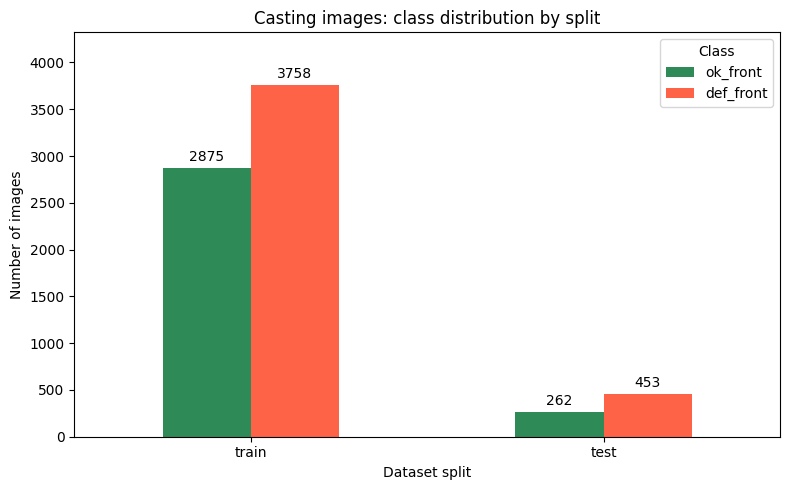

Class mapping: {'ok_front': 0, 'def_front': 1}
Positive class: def_front
Defect recall is the headline metric because it measures the proportion of actual defective castings detected.
Also report precision and F1 to assess false alarms. Accuracy alone can hide missed defects.


In [7]:
# TODO 1.1.3: root = data_prep.find_data_root(); count + plot class distribution by split

import importlib
import pandas as pd
import matplotlib.pyplot as plt
import config
from src import data_prep

importlib.reload(data_prep)

# 1. Locate images inside your dataset/ folder.
root = data_prep.find_data_root()
print("Dataset root:", root)

# 2. Count images per class in each original split.
rows = []

for split in ("train", "test"):
    image_paths = data_prep.list_images(root, split=split)

    for class_name, label in config.CLASS_TO_IDX.items():
        count = sum(
            path.relative_to(root).parts[1] == class_name
            for path in image_paths
        )

        rows.append({
            "split": split,
            "class": class_name,
            "label": label,
            "image_count": count,
        })

counts = pd.DataFrame(rows)

display(counts)
print("Total images:", counts["image_count"].sum())

if (counts["image_count"] == 0).any():
    raise ValueError("A class folder is empty. Check your dataset upload.")

# 3. Plot class distribution by split.
distribution = (
    counts.pivot(index="split", columns="class", values="image_count")
    .reindex(index=["train", "test"], columns=list(config.CLASS_TO_IDX))
)

ax = distribution.plot(
    kind="bar",
    figsize=(8, 5),
    color=["seagreen", "tomato"],
    rot=0,
)

ax.set_title("Casting images: class distribution by split")
ax.set_xlabel("Dataset split")
ax.set_ylabel("Number of images")
ax.legend(title="Class")

for container in ax.containers:
    ax.bar_label(container, padding=3)

ax.margins(y=0.15)
plt.tight_layout()
plt.show()

# 4. Confirm class meaning and the headline metric.
print("Class mapping:", config.CLASS_TO_IDX)
print("Positive class:", config.POSITIVE_CLASS)
print(
    "Defect recall is the headline metric because it measures "
    "the proportion of actual defective castings detected."
)
print(
    "Also report precision and F1 to assess false alarms. "
    "Accuracy alone can hide missed defects."
)

### 1.1.3 Dataset structure — findings

The dataset root is `data/casting_data/`, laid out as `{train,test}/{ok_front,def_front}/`. Every image is a 300 × 300 top-down photograph of a cast submersible-pump impeller, with greyscale content stored as JPEG.

| Split | ok_front (label 0) | def_front (label 1) | Total | Defect share |
|---|---|---|---|---|
| train | 2,875 | 3,758 | 6,633 | 56.7% |
| test | 262 | 453 | 715 | 63.4% |
| **Total** | **3,137** | **4,211** | **7,348** | **57.3%** |

**Observations**

- `def_front` is the **positive class (label 1)**, and it is also the majority class. The imbalance is mild, so resampling is not essential.
- Accuracy is still a poor headline metric: a model that labels *everything* defective would score 63.4% test accuracy while being useless.
- **Recall on `def_front` is the headline metric.** A missed defect (false negative) means a faulty casting ships, which costs far more than a false alarm (false positive) that only sends a good part to manual inspection.
- Precision and F1 on the defect class are reported alongside recall, so that high recall is not achieved simply by flagging everything.
- The original train and test folders overlap. This is investigated in Stage 1.2.

## **Stage 1.2 — Data Quality Validation** <font color="red">[5 marks]</font>

- **1.2.1 — Corrupt-file & image-dimension checks [2]**
- **1.2.2 — Duplicate detection (hashing) — leakage guard [2]**
- **1.2.3 — Class distribution + pass/fail report [1]**

**Objective:** Programmatically validate image quality before any split.

**Implement in:** src/data_prep.validate_quality

**Inputs → Outputs:** data root → a pass/fail report dict (corrupt, duplicates, dimensions, distribution)

**TODO:** check missing/corrupt files (Image.verify) and dimensions (1.2.1); detect DUPLICATE images via md5/hash (1.2.2); quantify class balance + print a pass/fail report (1.2.3); expect ~7,348 images, ~64 duplicates.

**Document here:** the quality report + why duplicate detection prevents train/test leakage.

In [8]:
def validate_quality(root, expected_size=(300, 300)):
    """
    Check image readability, dimensions, exact duplicates and class balance.

    passed=True means every BLOCKING check passed:
    - All required class folders contain readable images.
    - No missing/unreadable files.
    - No unexpected image dimensions.
    - No identical image stored under two different labels.

    Exact duplicates are REVIEW checks, not blocking: they are reported here
    and removed by build_splits() in Stage 1.3 (keeping the test copy).

    expected_size=None reports dimensions without enforcing a specific size.
    No images are changed or deleted.
    """
    from pathlib import Path
    from collections import Counter, defaultdict
    import hashlib
    from PIL import Image
    import config

    root = Path(root)
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    missing_folders = []
    missing_files = []
    corrupt = []
    unexpected_dimensions = []
    dimensions = Counter()
    hash_groups = defaultdict(list)
    distribution = {}
    total_images = 0

    for split in ("train", "test"):
        distribution[split] = {}

        for class_name in config.CLASS_TO_IDX:
            folder = root / split / class_name
            stats = {"found": 0, "readable": 0}
            distribution[split][class_name] = stats

            if not folder.is_dir():
                missing_folders.append(str(folder))
                continue

            paths = sorted(
                p for p in folder.rglob("*")
                if p.suffix.lower() in extensions
                and (p.is_file() or p.is_symlink())
            )

            stats["found"] = len(paths)
            total_images += len(paths)

            for path in paths:
                relative_path = path.relative_to(root).as_posix()

                if not path.exists():
                    missing_files.append(relative_path)
                    continue

                try:
                    # Verify image integrity.
                    with Image.open(path) as image:
                        image.verify()

                    # Reopen: verify() does not decode all image pixels.
                    with Image.open(path) as image:
                        image.load()
                        width, height = image.size

                    if width <= 0 or height <= 0:
                        raise ValueError("Invalid image dimensions")

                    stats["readable"] += 1
                    dimensions[f"{width}x{height}"] += 1

                    if (
                        expected_size is not None
                        and (width, height) != tuple(expected_size)
                    ):
                        unexpected_dimensions.append({
                            "path": relative_path,
                            "actual": [width, height],
                            "expected": list(expected_size),
                        })

                    # Hash file bytes to detect exact duplicate files.
                    digest = hashlib.sha256()
                    with path.open("rb") as image_file:
                        for chunk in iter(
                            lambda: image_file.read(1024 * 1024), b""
                        ):
                            digest.update(chunk)

                    hash_groups[digest.hexdigest()].append({
                        "path": relative_path,
                        "split": split,
                        "class": class_name,
                    })

                except FileNotFoundError:
                    missing_files.append(relative_path)

                except Exception as error:
                    corrupt.append({
                        "path": relative_path,
                        "error": str(error),
                    })

    duplicates = [
        {"sha256": digest, "files": files}
        for digest, files in hash_groups.items()
        if len(files) > 1
    ]

    cross_split_duplicates = [
        group for group in duplicates
        if len({file["split"] for file in group["files"]}) > 1
    ]

    label_conflicts = [
        group for group in duplicates
        if len({file["class"] for file in group["files"]}) > 1
    ]

    # Count extra copies, not the first image in each duplicate group.
    duplicate_count = sum(
        len(group["files"]) - 1 for group in duplicates
    )

    empty_classes = []

    for split, class_stats in distribution.items():
        split_total = sum(s["found"] for s in class_stats.values())

        for class_name, stats in class_stats.items():
            stats["percentage"] = (
                round(100 * stats["found"] / split_total, 2)
                if split_total else 0.0
            )

            if stats["readable"] == 0:
                empty_classes.append(f"{split}/{class_name}")

    # Blocking: the data cannot be used safely until these pass.
    blocking_checks = {
        "images_found": total_images > 0,
        "required_folders_present": not missing_folders,
        "no_missing_files": not missing_files,
        "no_corrupt_files": not corrupt,
        "dimensions_ok": not unexpected_dimensions,
        "all_classes_readable": not empty_classes,
        "no_label_conflicts": not label_conflicts,
    }

    # Review: reported issues that build_splits() resolves by deduplication.
    review_checks = {
        "no_exact_duplicates": not duplicates,
        "no_cross_split_duplicates": not cross_split_duplicates,
    }

    checks = {**blocking_checks, **review_checks}

    warnings = []

    if total_images != 7348:
        warnings.append(
            f"Found {total_images} image files; the template expects "
            "approximately 7348. Verify whether this is a sample."
        )

    if duplicates:
        warnings.append(
            f"{duplicate_count} exact duplicate copies found "
            f"({len(cross_split_duplicates)} groups span train and test). "
            "build_splits() keeps one copy per image (the test copy) "
            "so no image can appear in two final splits."
        )

    return {
        "root": str(root),
        "total_images": total_images,
        "expected_size": (
            list(expected_size) if expected_size is not None else None
        ),
        "missing_folders": missing_folders,
        "missing_files": missing_files,
        "corrupt": corrupt,
        "dimensions": dict(dimensions),
        "unexpected_dimensions": unexpected_dimensions,
        "distribution": distribution,
        "duplicate_group_count": len(duplicates),
        "duplicate_count": duplicate_count,
        "duplicates": duplicates,
        "cross_split_duplicates": cross_split_duplicates,
        "label_conflicts": label_conflicts,
        "empty_classes": empty_classes,
        "checks": checks,
        "blocking_checks": blocking_checks,
        "review_checks": review_checks,
        "passed": all(blocking_checks.values()),
        "fully_clean": all(checks.values()),
        "warnings": warnings,
    }

In [9]:
def load_split(version, name, root):
    """Load saved JSON records as (image_path, label) pairs."""
    import json
    from pathlib import Path
    import config

    if name not in ("train", "val", "test"):
        raise ValueError("name must be 'train', 'val', or 'test'.")

    manifest_path = Path(config.SPLIT_DIR) / version / f"{name}.json"

    if not manifest_path.is_file():
        raise FileNotFoundError(
            f"Split manifest not found: {manifest_path}. "
            f"Run build_splits(root, '{version}') first."
        )

    records = json.loads(manifest_path.read_text(encoding="utf-8"))
    root = Path(root)

    return [(root / record["path"], int(record["label"])) for record in records]

In [10]:
save_to_module(validate_quality, load_split)
print("validate_quality parameters:", inspect.signature(data_prep.validate_quality))

data_prep.py updated: validate_quality, load_split
validate_quality parameters: (root, expected_size=(300, 300))


In [11]:
# TODO 1.2.1-1.2.3: qc = data_prep.validate_quality(root); print(qc['total_images'], qc['passed'])
import importlib
import json
import pandas as pd
from pathlib import Path
from IPython.display import display
import config
from src import data_prep

importlib.reload(data_prep)

root = data_prep.find_data_root()
qc = data_prep.validate_quality(root, expected_size=(300, 300))

print("Total images scanned:", qc["total_images"])
print("Missing folders:", len(qc["missing_folders"]))
print("Missing files:", len(qc["missing_files"]))
print("Corrupt/unreadable files:", len(qc["corrupt"]))
print("Image dimensions:", qc["dimensions"])
print("Unexpected dimensions:", len(qc["unexpected_dimensions"]))
print("Duplicate groups:", qc["duplicate_group_count"])
print("Extra duplicate copies:", qc["duplicate_count"])
print("Cross-split duplicate groups:", len(qc["cross_split_duplicates"]))
print("Conflicting-label groups:", len(qc["label_conflicts"]))

print("\nClass distribution:")
display(pd.DataFrame([
    {"split": split, "class": class_name, **stats}
    for split, classes in qc["distribution"].items()
    for class_name, stats in classes.items()
]))

print("\nQuality checks:")
display(pd.DataFrame(
    [
        {"check": name, "type": "blocking", "result": "PASS" if ok else "FAIL"}
        for name, ok in qc["blocking_checks"].items()
    ]
    + [
        {
            "check": name,
            "type": "review",
            "result": "PASS" if ok else "REVIEW → resolved in Stage 1.3",
        }
        for name, ok in qc["review_checks"].items()
    ]
))

if not qc["passed"]:
    overall = "FAIL — fix blocking issues before splitting"
elif not qc["fully_clean"]:
    overall = "PASS (duplicates flagged; removed by build_splits in Stage 1.3)"
else:
    overall = "PASS"
print("\nOverall quality:", overall)

for warning in qc["warnings"]:
    print("NOTE:", warning)

# Show problem details when present.
for key in (
    "missing_folders",
    "missing_files",
    "corrupt",
    "unexpected_dimensions",
    "duplicates",
    "label_conflicts",
):
    if qc[key]:
        print(f"\n{key} — first 5 of {len(qc[key])}:")
        print(json.dumps(qc[key][:5], indent=2))

# Save the complete report.
report_path = Path(config.ARTIFACT_DIR) / "quality_report.json"
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(json.dumps(qc, indent=2), encoding="utf-8")
print("\nFull report saved to:", report_path)

Total images scanned: 7348
Missing folders: 0
Missing files: 0
Corrupt/unreadable files: 0
Image dimensions: {'300x300': 7348}
Unexpected dimensions: 0
Duplicate groups: 64
Extra duplicate copies: 64
Cross-split duplicate groups: 64
Conflicting-label groups: 0

Class distribution:


,split,class,found,readable,percentage
0,train,ok_front,2875,2875,43.34
1,train,def_front,3758,3758,56.66
2,test,ok_front,262,262,36.64
3,test,def_front,453,453,63.36



Quality checks:


,check,type,result
0,images_found,blocking,PASS
1,required_folders_present,blocking,PASS
2,no_missing_files,blocking,PASS
3,no_corrupt_files,blocking,PASS
4,dimensions_ok,blocking,PASS
5,all_classes_readable,blocking,PASS
6,no_label_conflicts,blocking,PASS
7,no_exact_duplicates,review,REVIEW → resolved in Stage 1.3
8,no_cross_split_duplicates,review,REVIEW → resolved in Stage 1.3



Overall quality: PASS (duplicates flagged; removed by build_splits in Stage 1.3)
NOTE: 64 exact duplicate copies found (64 groups span train and test). build_splits() keeps one copy per image (the test copy) so no image can appear in two final splits.

duplicates — first 5 of 64:
[
  {
    "sha256": "91d7d1d94402db60577a46547c0afadd7f737c779f6f381b7aa34dc5e059e37f",
    "files": [
      {
        "path": "train/ok_front/cast_ok_0_1001.jpeg",
        "split": "train",
        "class": "ok_front"
      },
      {
        "path": "test/ok_front/cast_ok_0_1001.jpeg",
        "split": "test",
        "class": "ok_front"
      }
    ]
  },
  {
    "sha256": "0b09411e68be8f06e90a7ef0480024833969389074e4798bf50f264c32d91e50",
    "files": [
      {
        "path": "train/ok_front/cast_ok_0_1002.jpeg",
        "split": "train",
        "class": "ok_front"
      },
      {
        "path": "test/ok_front/cast_ok_0_1002.jpeg",
        "split": "test",
        "class": "ok_front"
      }
    ]
  }

### 1.2 Data quality report — findings

| Check | Type | Result |
|---|---|---|
| Images found / required folders present | blocking | PASS (7,348 images, 4 folders) |
| Missing or corrupt files (`verify()` + full `load()`) | blocking | PASS (0) |
| Image dimensions | blocking | PASS (all 300 × 300) |
| Every class readable in every split | blocking | PASS |
| Identical image under two labels | blocking | PASS (0) |
| Exact duplicates (SHA-256 of file bytes) | review | 64 groups, 64 extra copies |
| Duplicates spanning train and test | review | 64 of 64 groups |

**Overall: PASS on all blocking checks. The duplicates are flagged for review and resolved in Stage 1.3.**

Class balance is 43.3% OK / 56.7% defective in train and 36.6% OK / 63.4% defective in test.

**What the duplicates are.** Each of the 64 groups is one file stored in *both* `train/` and `test/` under the same name and the same label, for example `cast_ok_0_1001.jpeg`. That means 64 of the 715 test images (9.0%) are also training images.

**Why duplicate detection prevents leakage.**

- If a test image was seen during training, the model's prediction on it reflects memorisation rather than generalisation. Test recall and precision would then be optimistically biased, and we would overestimate how the model performs on new castings.
- Hashing the file *contents*, rather than comparing names, catches identical images even when they are renamed or moved. It also avoids falsely flagging different images that happen to share a name.
- Detection runs **before** any split, so the fix can be built into the split itself. Stage 1.3 keeps the test copy of each duplicate and drops the training copy, then asserts that no hash appears in two final splits.
- **Limitation:** exact hashing cannot detect *near*-duplicates, such as a re-encoded, resized or slightly shifted photo of the same part. Perceptual hashing (e.g. pHash) would be the next step if that risk matters.

## **Stage 1.3 — Dataset Versioning & Metadata** <font color="red">[5 marks]</font>

- **1.3.1 — Reproducible, stratified train/val/test split [3]**
- **1.3.2 — Split snapshot + metadata.json (versioning) [2]**

**Objective:** Create reproducible, versioned splits.

**Implement in:** src/data_prep.build_splits

**Inputs → Outputs:** data root + version id → train/val/test file lists + metadata.json

**TODO:** make a STRATIFIED train/val/test split (seed 42) (1.3.1); snapshot the file lists + write metadata.json (version id, date, class defs, split sizes, seed) (1.3.2).

**Document here:** the split sizes + the metadata record.

In [12]:
def build_splits(root, version="v1"):
    from pathlib import Path
    from collections import defaultdict, Counter
    from datetime import datetime, timezone
    import hashlib
    import json
    import re

    from PIL import Image
    from sklearn.model_selection import train_test_split
    import config

    root = Path(root).resolve()
    seed = getattr(config, "SEED", 42)  # brief requires seed 42
    val_fraction = config.VAL_SPLIT

    if not re.fullmatch(r"[A-Za-z0-9_-]+", version):
        raise ValueError("Use a version such as v1 or v2.")

    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    groups = defaultdict(list)
    inventory = []

    # Read and hash all images again so the snapshot matches current data.
    for split in ("train", "test"):
        for class_name, label in config.CLASS_TO_IDX.items():
            folder = root / split / class_name

            if not folder.is_dir():
                raise FileNotFoundError(f"Missing folder: {folder}")

            paths = sorted(
                p for p in folder.rglob("*")
                if p.is_file() and p.suffix.lower() in extensions
            )

            if not paths:
                raise ValueError(f"No images in {folder}")

            for path in paths:
                # Stop if an unreadable image is encountered.
                with Image.open(path) as image:
                    image.verify()
                with Image.open(path) as image:
                    image.load()

                hasher = hashlib.sha256()
                with path.open("rb") as file:
                    for chunk in iter(lambda: file.read(1024 * 1024), b""):
                        hasher.update(chunk)

                record = {
                    "path": path.relative_to(root).as_posix(),
                    "label": int(label),
                    "class": class_name,
                    "source_split": split,
                    "sha256": hasher.hexdigest(),
                }

                inventory.append(record)
                groups[record["sha256"]].append(record)

    # Keep one copy per hash. Prefer the original test copy.
    retained = []
    excluded = []

    for digest in sorted(groups):
        copies = groups[digest]

        if len({r["label"] for r in copies}) > 1:
            raise ValueError(
                "Identical image has conflicting labels: "
                + str([r["path"] for r in copies])
            )

        copies = sorted(
            copies,
            key=lambda r: (
                0 if r["source_split"] == "test" else 1,
                r["path"],
            ),
        )

        retained.append(copies[0])

        for duplicate in copies[1:]:
            excluded.append({
                **duplicate,
                "kept_path": copies[0]["path"],
                "reason": "exact_duplicate",
            })

    train_pool = sorted(
        [r for r in retained if r["source_split"] == "train"],
        key=lambda r: r["path"],
    )

    test = sorted(
        [r for r in retained if r["source_split"] == "test"],
        key=lambda r: r["path"],
    )

    required_labels = set(config.CLASS_TO_IDX.values())

    for name, records in (("training pool", train_pool), ("test", test)):
        if {r["label"] for r in records} != required_labels:
            raise ValueError(f"A class is missing from the {name}.")

    try:
        train, val = train_test_split(
            train_pool,
            test_size=val_fraction,
            random_state=seed,
            stratify=[r["label"] for r in train_pool],
        )
    except ValueError as error:
        raise ValueError(
            "Not enough images per class for the requested "
            "stratified validation split."
        ) from error

    splits = {
        "train": sorted(train, key=lambda r: r["path"]),
        "val": sorted(val, key=lambda r: r["path"]),
        "test": test,
    }

    # Confirm all final splits contain both classes.
    for name, records in splits.items():
        if {r["label"] for r in records} != required_labels:
            raise ValueError(f"A class is missing from the {name} split.")

    # Prove no exact duplicate contents cross final splits.
    hashes = {
        name: {r["sha256"] for r in records}
        for name, records in splits.items()
    }

    for first, second in (("train", "val"), ("train", "test"), ("val", "test")):
        if hashes[first] & hashes[second]:
            raise ValueError(f"Leakage detected between {first} and {second}.")

    fingerprint = hashlib.sha256(
        json.dumps(
            sorted(inventory, key=lambda r: r["path"]),
            sort_keys=True,
        ).encode()
    ).hexdigest()

    metadata = {
        "version": version,
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "dataset_root": str(root),
        "dataset_fingerprint": fingerprint,
        "seed": seed,
        "validation_fraction_of_clean_train": val_fraction,
        "class_to_idx": dict(config.CLASS_TO_IDX),
        "positive_class": config.POSITIVE_CLASS,
        "original_image_count": len(inventory),
        "unique_image_count": len(retained),
        "excluded_duplicate_count": len(excluded),
        "split_policy": (
            "Preserve original test membership after deduplication. "
            "Prefer test copies; stratify remaining train into train/val."
        ),
        "cross_split_hash_overlap": 0,
        "split_info": {
            name: {
                "size": len(records),
                "class_counts": {
                    class_name: sum(
                        r["class"] == class_name for r in records
                    )
                    for class_name in config.CLASS_TO_IDX
                },
            }
            for name, records in splits.items()
        },
    }

    output_dir = Path(config.SPLIT_DIR) / version
    payloads = {
        **{f"{name}.json": records for name, records in splits.items()},
        "excluded_duplicates.json": excluded,
    }

    # Preserve existing versions; reuse only if data and split results match.
    if output_dir.exists():
        metadata_path = output_dir / "metadata.json"

        if not metadata_path.is_file():
            raise ValueError("Incomplete existing version. Use a new version.")

        previous = json.loads(metadata_path.read_text())

        same_settings = all(
            previous.get(key) == metadata[key]
            for key in (
                "dataset_fingerprint",
                "seed",
                "validation_fraction_of_clean_train",
                "class_to_idx",
                "positive_class",
                "split_policy",
            )
        )

        same_files = all(
            (output_dir / name).is_file()
            and json.loads((output_dir / name).read_text()) == content
            for name, content in payloads.items()
        )

        if not (same_settings and same_files):
            raise ValueError(
                f"{version} already contains different data or splits. "
                "Choose a new version, such as v2."
            )

        return previous

    output_dir.mkdir(parents=True)

    for name, content in payloads.items():
        (output_dir / name).write_text(
            json.dumps(content, indent=2), encoding="utf-8"
        )

    (output_dir / "metadata.json").write_text(
        json.dumps(metadata, indent=2), encoding="utf-8"
    )

    return metadata

In [13]:
save_to_module(build_splits)

data_prep.py updated: build_splits


In [14]:
# TODO 1.3.1-1.3.2: meta = data_prep.build_splits(root, 'v1'); print(meta['split_info'])
import json
import pandas as pd
import config
from IPython.display import display
from src import data_prep

root = data_prep.find_data_root()

VERSION = "v1"  # Use v2 if v1 already holds different splits.
meta = data_prep.build_splits(root, VERSION)

print("Split sizes and class counts:")

display(pd.DataFrame([
    {
        "split": split,
        "total": info["size"],
        **info["class_counts"],
    }
    for split, info in meta["split_info"].items()
]))

print("\nOriginal images:", meta["original_image_count"])
print("Unique images:", meta["unique_image_count"])
print("Duplicate copies excluded:", meta["excluded_duplicate_count"])
print("Cross-split hash overlap:", meta["cross_split_hash_overlap"])

print("\nMetadata:")
print(json.dumps(meta, indent=2))

print("\nSnapshot folder:", config.SPLIT_DIR / VERSION)

Split sizes and class counts:


,split,total,ok_front,def_front
0,train,5583,2389,3194
1,val,986,422,564
2,test,715,262,453



Original images: 7348
Unique images: 7284
Duplicate copies excluded: 64
Cross-split hash overlap: 0

Metadata:
{
  "version": "v1",
  "created_utc": "2026-10-07T09:58:27.685025+00:00",
  "dataset_root": "/content/drive/MyDrive/Casting_Defect_MLOps_Capstone/data/casting_data",
  "dataset_fingerprint": "907a855bb7e9041cb3cfa856a9d0fbd0750dd562ccca959fb41f44c669496f92",
  "seed": 42,
  "validation_fraction_of_clean_train": 0.15,
  "class_to_idx": {
    "ok_front": 0,
    "def_front": 1
  },
  "positive_class": "def_front",
  "original_image_count": 7348,
  "unique_image_count": 7284,
  "excluded_duplicate_count": 64,
  "split_policy": "Preserve original test membership after deduplication. Prefer test copies; stratify remaining train into train/val.",
  "cross_split_hash_overlap": 0,
  "split_info": {
    "train": {
      "size": 5583,
      "class_counts": {
        "ok_front": 2389,
        "def_front": 3194
      }
    },
    "val": {
      "size": 986,
      "class_counts": {
       

In [15]:
# Reload the saved snapshot and confirm it matches metadata.json.
import importlib
import json
from collections import Counter
from pathlib import Path
import config
from src import data_prep

importlib.reload(data_prep)

VERSION = "v1"
root = data_prep.find_data_root()
saved_meta = json.loads(
    (Path(config.SPLIT_DIR) / VERSION / "metadata.json").read_text(encoding="utf-8")
)
idx_to_class = {idx: name for name, idx in config.CLASS_TO_IDX.items()}

for split in ("train", "val", "test"):
    records = data_prep.load_split(VERSION, split, root)
    counts = Counter(idx_to_class[label] for _, label in records)
    missing = [path for path, _ in records if not path.is_file()]

    assert len(records) == saved_meta["split_info"][split]["size"]
    assert dict(counts) == saved_meta["split_info"][split]["class_counts"]
    assert not missing, f"{len(missing)} files listed in {split} are missing"

    print(f"{split}: {len(records)} images {dict(counts)} — matches metadata")

train: 5583 images {'def_front': 3194, 'ok_front': 2389} — matches metadata
val: 986 images {'def_front': 564, 'ok_front': 422} — matches metadata
test: 715 images {'def_front': 453, 'ok_front': 262} — matches metadata


### 1.3 Versioned splits — findings

| Split | ok_front | def_front | Total | OK share |
|---|---|---|---|---|
| train | 2,389 | 3,194 | 5,583 | 42.8% |
| val | 422 | 564 | 986 | 42.8% |
| test | 262 | 453 | 715 | 36.6% |
| **Total (unique)** | | | **7,284** | |

The original 7,348 images minus 64 duplicate copies leaves 7,284 unique images. The hash overlap between any two final splits is **0**.

**Split policy (1.3.1)**

1. Deduplicate by SHA-256, keeping the **test** copy of each duplicate.
2. Keep the original Kaggle test folder as the held-out **test** set.
3. Split the remaining training images **stratified by label** into train (85%) and val (15%, `config.VAL_SPLIT`), using `random_state = 42`.

Records are sorted by path before splitting, so the result does not depend on file-system ordering. The same data therefore always produces the same split.

**Why the original test set is kept rather than pooled and re-split.** The test folder was assembled independently by the dataset authors. Keeping it makes results comparable with other work on this dataset and avoids reshuffling a set the authors held out.

The trade-off is that test has a slightly different class mix (36.6% OK) from train and val (42.8% OK, identical thanks to stratification). Recall does not depend on class prevalence, but precision does. Validation and test precision should therefore be compared with this difference in mind.

**Snapshot and metadata (1.3.2).** `artifacts/splits/v1/` contains:

- `train.json`, `val.json` and `test.json`: one record per image with its relative path, label, class, original split and SHA-256.
- `excluded_duplicates.json`: each dropped copy and the copy that was kept.
- `metadata.json`: version id, UTC creation time, dataset fingerprint (a hash of the full image inventory), seed, validation fraction, class definitions, positive class, image counts before and after deduplication, split policy, and split sizes with class counts.

Versions are **immutable**. Re-running `build_splits(root, "v1")` on unchanged data returns the stored metadata. If the data or settings change, it refuses to overwrite and asks for a new version such as `v2`.

## **Stage 1.4 — EDA & Methodology Design** <font color="red">[5 marks]</font>

- **1.4.1 — Image-characteristic EDA [3]** — *to be done in this notebook and the report*
- **1.4.2 — End-to-end MLOps workflow design [2]** — *to be done in the report*

**Objective:** Explore image characteristics that motivate preprocessing + drift features.

**Implement in:** this notebook (+ src/data_prep.image_features)

**Inputs → Outputs:** sample images → a feature table (brightness/contrast/edge/sharpness/dark-ratio) by class

**TODO:** show a sample grid (OK vs Defective) + per-class feature means (1.4.1); in the report, design the end-to-end MLOps workflow (1.4.2).

**Document here:** an interpretation cell (1.4.1) + the workflow design in the report (1.4.2).

In [16]:
def image_features(image):
    """Calculate descriptive features from a PIL image or image path."""
    from pathlib import Path
    import numpy as np
    from PIL import Image

    if isinstance(image, (str, Path)):
        with Image.open(image) as img:
            gray = np.asarray(img.convert("L"), dtype=np.float32)
    else:
        gray = np.asarray(image.convert("L"), dtype=np.float32)

    if min(gray.shape) < 3:
        raise ValueError("Image must be at least 3 × 3 pixels.")

    # Gradient magnitude: strength of intensity changes.
    gradient_y, gradient_x = np.gradient(gray)
    gradient = np.hypot(gradient_x, gradient_y)

    # Discrete Laplacian, excluding image borders.
    laplacian = (
        gray[:-2, 1:-1]
        + gray[2:, 1:-1]
        + gray[1:-1, :-2]
        + gray[1:-1, 2:]
        - 4 * gray[1:-1, 1:-1]
    )

    return {
        "brightness": float(gray.mean()),
        "contrast": float(gray.std()),
        "edge_density": float((gradient > 20).mean()),
        "sharpness": float(laplacian.var()),
        "dark_ratio": float((gray < 50).mean()),
        # Compatibility with the supplied monitoring configuration.
        "mean_intensity": float(gray.mean()),
    }

In [17]:
save_to_module(image_features)

data_prep.py already up to date: image_features


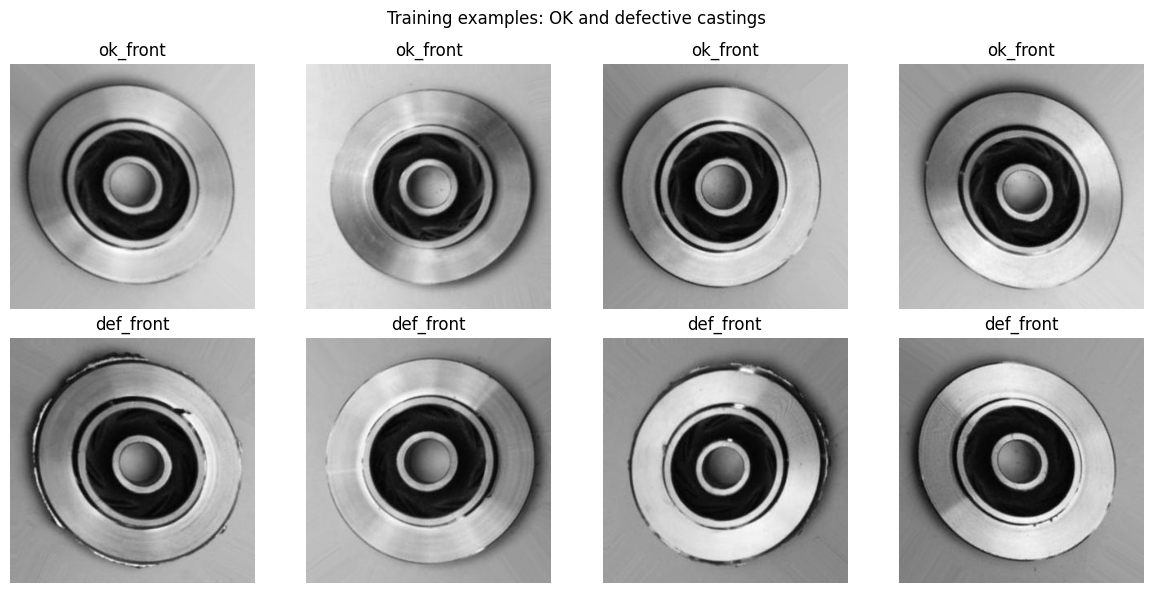

Training images analysed per class:


,image_count
class,
ok_front,2389
def_front,3194


Per-class feature means:


,brightness,contrast,edge_density,sharpness,dark_ratio
class,,,,,
ok_front,149.8767,62.3016,0.0722,170.5273,0.1338
def_front,139.2783,58.6064,0.0786,192.2653,0.1394


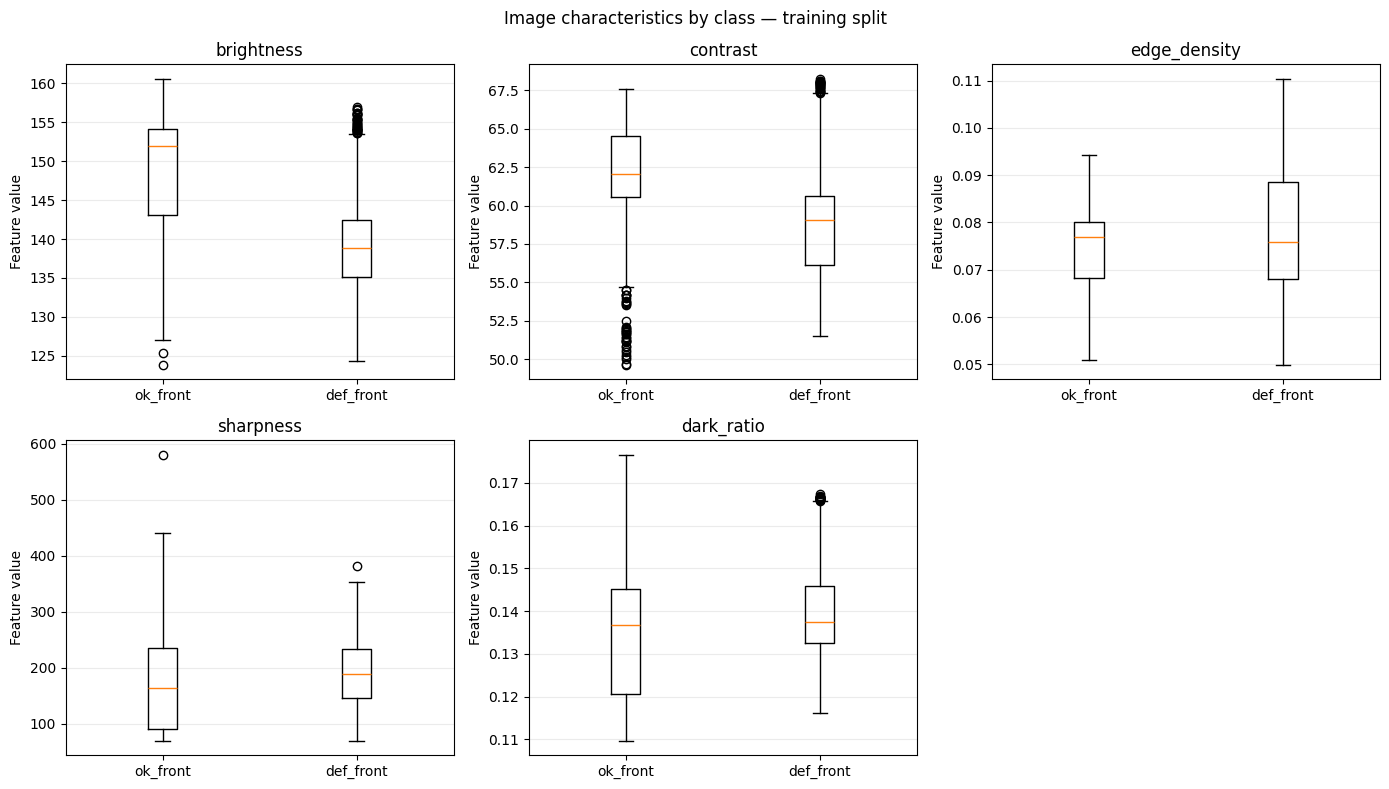


Observed mean differences:
brightness: OK=149.8767, defective=139.2783, difference=-10.5985
contrast: OK=62.3016, defective=58.6064, difference=-3.6952
edge_density: OK=0.0722, defective=0.0786, difference=+0.0064
sharpness: OK=170.5273, defective=192.2653, difference=+21.7380
dark_ratio: OK=0.1338, defective=0.1394, difference=+0.0056

EDA evidence saved to: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/artifacts/eda/v1


In [18]:
# TODO 1.4.1: sample-image grid; per-class image_features means
import json
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import config
from src import data_prep

VERSION = "v1"
root = data_prep.find_data_root()
split_dir = Path(config.SPLIT_DIR) / VERSION

train_records = json.loads(
    (split_dir / "train.json").read_text(encoding="utf-8")
)

if not train_records:
    raise ValueError("The saved training split is empty.")

# Save EDA evidence separately for each dataset version.
output_dir = Path(config.ARTIFACT_DIR) / "eda" / VERSION
output_dir.mkdir(parents=True, exist_ok=True)

class_names = list(config.CLASS_TO_IDX)
rng = random.Random(42)

# 1. Sample-image grid.
fig, axes = plt.subplots(
    len(class_names), 4,
    figsize=(12, 6),
    squeeze=False,
)

for row_index, class_name in enumerate(class_names):
    candidates = [
        record for record in train_records
        if record["class"] == class_name
    ]

    if not candidates:
        raise ValueError(f"No training images for {class_name}")

    samples = rng.sample(candidates, min(4, len(candidates)))

    for ax in axes[row_index]:
        ax.axis("off")

    for ax, record in zip(axes[row_index], samples):
        with Image.open(root / record["path"]) as image:
            ax.imshow(image.convert("L"), cmap="gray", vmin=0, vmax=255)

        ax.set_title(class_name)

fig.suptitle("Training examples: OK and defective castings")
plt.tight_layout()
fig.savefig(output_dir / "sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Feature table for every retained training image.
feature_rows = []

for record in train_records:
    feature_rows.append({
        "path": record["path"],
        "class": record["class"],
        **data_prep.image_features(root / record["path"]),
    })

features = pd.DataFrame(feature_rows)

feature_columns = [
    "brightness",
    "contrast",
    "edge_density",
    "sharpness",
    "dark_ratio",
]

print("Training images analysed per class:")
display(
    features.groupby("class")
    .size()
    .reindex(class_names)
    .rename("image_count")
    .to_frame()
)

class_means = (
    features.groupby("class")[feature_columns]
    .mean()
    .reindex(class_names)
)

print("Per-class feature means:")
display(class_means.round(4))

# 3. Inspect overlap and variation, not just averages.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, feature in zip(axes.flat, feature_columns):
    values = [
        features.loc[features["class"] == cls, feature].to_numpy()
        for cls in class_names
    ]

    ax.boxplot(values)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(class_names)
    ax.set_title(feature)
    ax.set_ylabel("Feature value")
    ax.grid(axis="y", alpha=0.25)

axes.flat[-1].axis("off")
fig.suptitle("Image characteristics by class — training split")
plt.tight_layout()
fig.savefig(
    output_dir / "feature_distributions.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# 4. Save evidence.
features.to_csv(output_dir / "training_image_features.csv", index=False)
class_means.to_csv(output_dir / "class_feature_means.csv")

# Generate factual comparisons from the measured results.
print("\nObserved mean differences:")

for feature in feature_columns:
    ok_mean = class_means.loc["ok_front", feature]
    defect_mean = class_means.loc["def_front", feature]
    difference = defect_mean - ok_mean

    print(
        f"{feature}: OK={ok_mean:.4f}, "
        f"defective={defect_mean:.4f}, "
        f"difference={difference:+.4f}"
    )

print("\nEDA evidence saved to:", output_dir)

### 1.4.1 EDA interpretation

The per-class means and box plots above are computed on the **training split only**, so the test set is not inspected.

| Feature | OK mean | Defective mean | What the box plots show |
|---|---|---|---|
| brightness | 149.9 | 139.3 | Clearest difference: the interquartile ranges barely overlap |
| contrast | 62.3 | 58.6 | OK is higher on average, with moderate overlap and some low-contrast OK outliers |
| edge_density | 0.072 | 0.079 | Similar medians; defective images have a wider spread (up to about 0.11) |
| sharpness | 170.5 | 192.3 | Heavy overlap; OK images vary more |
| dark_ratio | 0.134 | 0.139 | Heavy overlap |

**Interpretation**

- **Defects are local.** Blowholes, burrs and cracks occupy a small area of each casting, so whole-image averages barely move. Edge density, sharpness and dark ratio overlap almost completely between the classes. No single global statistic separates OK from defective, which justifies a CNN that learns spatial patterns, here a pretrained ResNet18.
- **Brightness is a possible shortcut.** Defective images are darker on average and the two distributions are fairly well separated. A brightness difference of this size more plausibly reflects capture conditions (lighting or exposure per batch) than the defects themselves. If so, a model could learn "darker = defective" and fail when lighting changes in production. This motivates two later choices:
  - brightness and contrast jitter in training augmentation (Stage 2.1);
  - brightness and contrast as monitored drift features.
- **Preprocessing implications.**
  - All images are already 300 × 300 with greyscale content. A plain resize to 224 and replicating the grey channel three times is enough to match ResNet18's RGB input.
  - Parts are photographed top-down and roughly centred. Flips, small rotations and small shifts produce realistic variations without changing the label.
- **Monitoring.** The same `image_features()` function provides reference distributions for drift detection on incoming production images.

## **Stage 2.1 — Preprocessing & Augmentation** <font color="red">[6 marks]</font>

- **2.1.1 — Convert greyscale image to 3-channel RGB, resize 224, ImageNet normalise [3]**
- **2.1.2 — Train-only augmentation (val/test none) [3]**

**Objective:** Build transforms that match the pretrained ResNet18 backbone.

**Implement in:** src/data_prep.get_transforms

**Inputs → Outputs:** a PIL image → a (3,224,224) normalised tensor; train transform adds augmentation

**TODO:** Convert greyscale image to 3-channel RGB, Resize 224, ImageNet normalise (2.1.1); train-time augmentation (flip/rotation/translate/colour jitter) with val/test NO augmentation (2.1.2).

**Document here:** a before/after visualisation of the transforms.

In [19]:
def get_transforms(train=False):
    """Convert a PIL image into a normalized 3 × 224 × 224 tensor."""
    import config
    from torchvision import transforms as T

    operations = [
        # Replicate grayscale information across three channels.
        T.Grayscale(num_output_channels=3),
        T.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    ]

    if train:
        operations.extend([
            T.RandomHorizontalFlip(p=config.AUG["hflip_p"]),

            # Random rotation and translation in one operation.
            T.RandomAffine(
                degrees=config.AUG["rotation_degrees"],
                translate=(
                    config.AUG["translate"],
                    config.AUG["translate"],
                ),
                interpolation=T.InterpolationMode.BILINEAR,
                fill=128,
            ),

            T.ColorJitter(
                brightness=config.AUG["brightness"],
                contrast=config.AUG["contrast"],
            ),
        ])

    operations.extend([
        # Convert pixels from 0–255 to a float tensor in 0–1.
        T.ToTensor(),

        # Normalize each channel using ImageNet statistics.
        T.Normalize(
            mean=config.IMAGENET_MEAN,
            std=config.IMAGENET_STD,
        ),
    ])

    return T.Compose(operations)

In [20]:
save_to_module(get_transforms)

data_prep.py already up to date: get_transforms


Sample: cast_def_0_1000.jpeg
Output shape: (3, 224, 224)
Output dtype: torch.float32
Shape and finite-value checks: PASS
Deterministic evaluation check: PASS
ImageNet normalization check: PASS

Training transform:
Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomAffine(degrees=[-15.0, 15.0], translate=(0.05, 0.05), interpolation=bilinear, fill=128)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/test transform:
Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


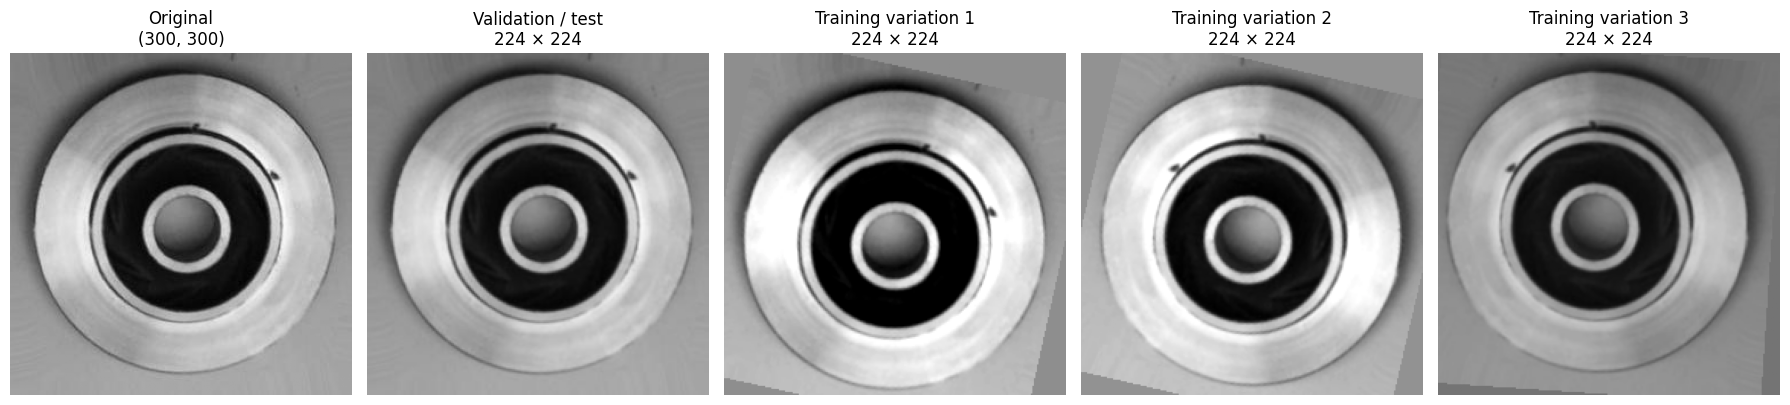


Visualisation saved to: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/artifacts/preprocessing/v1/preprocessing_augmentation.png


In [21]:
# TODO 2.1.1-2.1.2: tf=data_prep.get_transforms(train=True); verify a sample tensor is (3,224,224)
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import config
from src import data_prep

VERSION = "v1"
root = data_prep.find_data_root()

train_records = json.loads(
    (Path(config.SPLIT_DIR) / VERSION / "train.json")
    .read_text(encoding="utf-8")
)

if not train_records:
    raise ValueError("Training manifest is empty.")

sample_path = root / train_records[0]["path"]

with Image.open(sample_path) as image:
    original = image.convert("L")

train_tf = data_prep.get_transforms(train=True)
eval_tf = data_prep.get_transforms(train=False)

# Seed only the demonstration, preserving the surrounding RNG state.
with torch.random.fork_rng(devices=[]):
    torch.manual_seed(42)
    augmented = [train_tf(original) for _ in range(3)]

eval_tensor = eval_tf(original)
eval_repeat = eval_tf(original)

# 1. Check tensor dimensions, type, and values.
for tensor in [eval_tensor, *augmented]:
    assert tuple(tensor.shape) == (3, 224, 224)
    assert tensor.dtype == torch.float32
    assert torch.isfinite(tensor).all().item()

# 2. Validation/test preprocessing must be deterministic.
assert torch.equal(eval_tensor, eval_repeat)

# 3. Verify normalization against the pre-normalized image.
from torchvision import transforms as T

before_normalization = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    T.ToTensor(),
])(original)

mean = torch.tensor(config.IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(config.IMAGENET_STD).view(3, 1, 1)

expected = (before_normalization - mean) / std
assert torch.allclose(eval_tensor, expected)

print("Sample:", sample_path.name)
print("Output shape:", tuple(eval_tensor.shape))
print("Output dtype:", eval_tensor.dtype)
print("Shape and finite-value checks: PASS")
print("Deterministic evaluation check: PASS")
print("ImageNet normalization check: PASS")

print("\nTraining transform:")
print(train_tf)

print("\nValidation/test transform:")
print(eval_tf)

# Undo normalization only for display.
def display_tensor(tensor):
    restored = tensor.detach().cpu() * std + mean
    return restored.clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(original, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Original\n{original.size}")

axes[1].imshow(display_tensor(eval_tensor))
axes[1].set_title("Validation / test\n224 × 224")

for index, tensor in enumerate(augmented, start=2):
    axes[index].imshow(display_tensor(tensor))
    axes[index].set_title(f"Training variation {index - 1}\n224 × 224")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

output_dir = Path(config.ARTIFACT_DIR) / "preprocessing" / VERSION
output_dir.mkdir(parents=True, exist_ok=True)

figure_path = output_dir / "preprocessing_augmentation.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("\nVisualisation saved to:", figure_path)

### 2.1 Preprocessing and augmentation — findings

**Validation/test transform (2.1.1).** The pipeline is deterministic:

1. `Grayscale(num_output_channels=3)` replicates the single grey channel into the three channels ResNet18 expects.
2. `Resize((224, 224))`.
3. `ToTensor()` scales pixel values to the range 0–1.
4. `Normalize` applies the ImageNet mean and standard deviation, the statistics the pretrained weights were trained with.

The checks above confirm the output is a finite `float32` tensor of shape (3, 224, 224). They also confirm that applying the transform twice gives identical output, and that the normalisation matches `(x − mean) / std` exactly.

**Training-only augmentation (2.1.2).** Training adds three random operations:

- horizontal flip (p = 0.5);
- one affine transform with rotation up to ±15° and translation up to ±5%;
- brightness and contrast jitter of ±20%.

Each one keeps the label valid. A flipped, slightly rotated or slightly shifted top-down photo of a sound casting is still sound, and a defect stays a defect. The jitter specifically targets the brightness difference found in 1.4.1, so the model has to rely on the defect itself rather than the lighting. The flat grey corners visible in the training variations are the fill value (128) for pixels exposed by rotation or translation.

Validation and test get **no augmentation**, so their metrics are reproducible and reflect real inputs.

**Trade-off:** resizing 300 → 224 shrinks very small defects by about 25%. This is accepted to keep the standard ResNet18 input size.

---
**Outputs feed Stage 2.2+** in `Model_Development_and_Tracking.ipynb` (the versioned splits + transforms are reused to train the model).